In [1]:
import time
import random
import numpy as np
np.set_printoptions(suppress=True, precision=6)

import matplotlib.pyplot as plt
from scipy.special import erf

import sys
sys.path.insert(0, '/home/ferjao_k/sw/aare/build')

from aare import fit_scurve, fit_scurve2          # lmfit
from aare import RisingScurve, FallingScurve, fit # minuit2 (object based API)

from pprint import pprint

## Model curves

In [2]:
def scurve(x, p): # rising Scurve
    p0, p1, p2, p3, p4, p5 = p
    return (p0 + p1*x) + 0.5 *(1 + erf((x-p2) / (np.sqrt(2)*p3))) * (p4 + p5*(x-p2))

def scurve2(x, p): #falling Scurve
    p0, p1, p2, p3, p4, p5 = p
    return (p0 + p1*x) + 0.5 *(1 - erf((x-p2) / (np.sqrt(2)*p3))) * (p4 + p5*(x-p2))

## Generate data (1D)

In [3]:
x = np.linspace(0,120, 121)

rng = np.random.default_rng(42)
0
p_true_rising = np.array([100.0, 0.25, 60.0, 6.0, 120.0,  1.0])
p_true_falling = np.array([100.0, 0.25, 60.0, 6.0, 120.0, -1.0])

y_true_rising = scurve(x, p_true_rising)
y_true_falling = scurve2(x, p_true_falling)

noise_sigma = 4

y_rising = y_true_rising + rng.normal(0, noise_sigma, size=x.shape)
# y_err_r = np.full_like(x, noise_sigma)

y_falling = y_true_falling + rng.normal(0, noise_sigma, size=x.shape)
# y_err_f = np.full_like(x, noise_sigma)

## Plot synthetic data

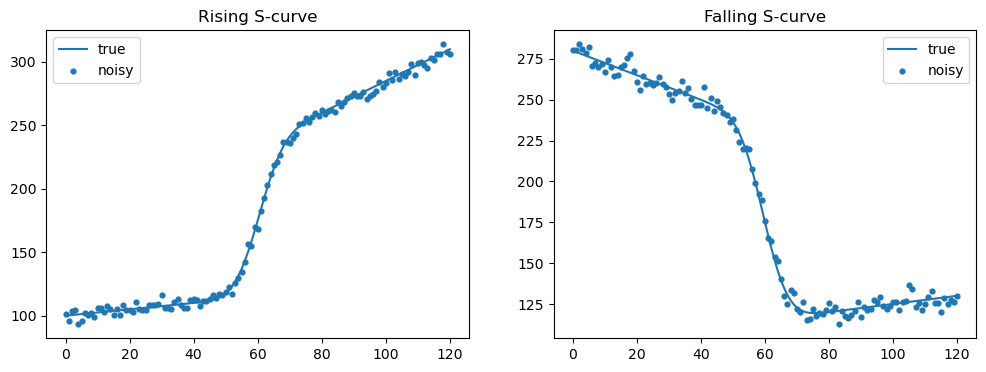

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12,4), sharex=True)

ax[0].plot(x, y_true_rising, label="true")
ax[0].scatter(x, y_rising, s=12, label="noisy")
ax[0].set_title("Rising S-curve")
ax[0].legend()

ax[1].plot(x, y_true_falling, label="true")
ax[1].scatter(x, y_falling, s=12, label="noisy")
ax[1].set_title("Falling S-curve")
ax[1].legend()

plt.show()

## Fit the Rising S-curve

In [18]:
res_r_lmfit = fit_scurve(x, y_rising)

model_r = RisingScurve()
print("Paramter list of the Scurve:")
# print(model_r.GetParNames())
print(model_r.par_names)
print(model_r.n_par, '\n')

model_r.FixParameter('p0', 100)  # Fixed p0 = 100 (optimizer does not touch the value)
model_r.SetParameter('A', 100) # Start value A = 100

print("== Tuned fit settings ==")
model_r.compute_errors = True
model_r.max_calls = 500
model_r.tolerance = 0.01
print(f"max_calls : {model_r.max_calls}")
print(f"tolerance : {model_r.tolerance}")
print(f"compute_erros: {model_r.compute_errors}")
print("\n")
print("== Results ==")
res_r_munuit_obj = model_r.fit(x, y_rising, np.sqrt(y_rising))

print("True rising params:         ", p_true_rising)
print("lmfit rising result:        ", res_r_lmfit)
print("minuit_grad (obj api ) rising result:")
pprint(res_r_munuit_obj, sort_dicts=False)

Paramter list of the Scurve:
['p0', 'p1', 'mu', 'sigma', 'A', 'C']
6 

== Tuned fit settings ==
max_calls : 500
tolerance : 0.01
compute_erros: True


== Results ==
True rising params:          [100.     0.25  60.     6.   120.     1.  ]
lmfit rising result:         [ 99.467831   0.287017  60.078405   5.715461 117.257939   0.967234]
minuit_grad (obj api ) rising result:
{'par': array([100.      ,   0.269137,  60.050193,   5.729932, 117.777635,
         0.984073]),
 'par_err': array([1.      , 0.054406, 0.747753, 0.909864, 7.887499, 0.174058]),
 'chi2': array([7.351743])}


## Fit the Falling S-curve

In [19]:
res_f_lmfit = fit_scurve2(x, y_falling)

model_f = FallingScurve()
model_f.SetParameter(2, 20) # set start p2 = 20
model_f.SetParameter(4, 90) # set start p4 = 90
model_f.SetParLimits(4, 80, 130)
model_f.max_calls = 150 # this is limits the number of calls done by the minimizer (increasing the `max_calls` may help if the fit fails) 
res_f_munuit_obj = model_f.fit(x, y_falling)

print("True falling params:  ", p_true_falling)
print("lmfit falling result:  ", res_f_lmfit)
print("minuit_grad (obj api ) falling result")
pprint(res_f_munuit_obj, sort_dicts=False)

True falling params:   [100.     0.25  60.     6.   120.    -1.  ]
lmfit falling result:   [101.73448    0.225786  60.251971   6.092915 118.476735  -0.998677]
minuit_grad (obj api ) falling result
{'par': array([101.741754,   0.225723,  60.251604,   6.092887, 118.473268,
        -0.998565]),
 'chi2': array([1865.728797])}


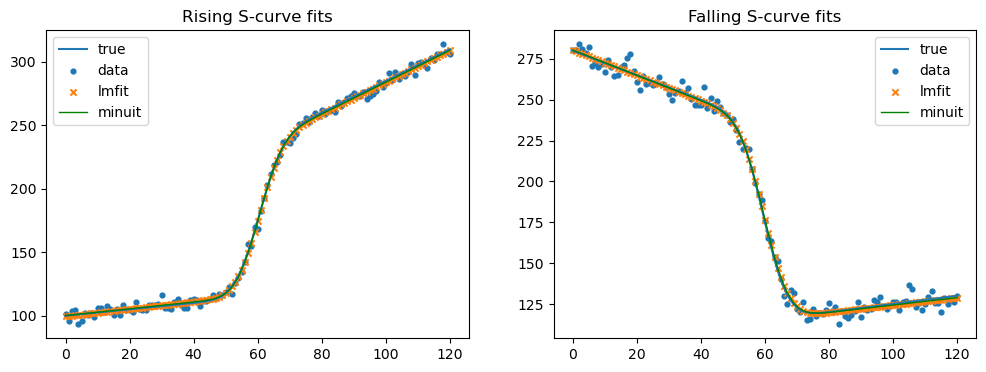

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

# rising
ax[0].plot(x, y_true_rising, label="true")
ax[0].scatter(x, y_rising, s=12, label="data")
ax[0].scatter(x, scurve(x, res_r_lmfit[:6]), s=20, marker="x", label="lmfit")
ax[0].plot(x, model_r(x, res_r_munuit_obj['par']), linewidth=1, color="green", label="minuit")
ax[0].set_title("Rising S-curve fits")
ax[0].legend()

# falling
ax[1].plot(x, y_true_falling, label="true")
ax[1].scatter(x, y_falling, s=12, label="data")
ax[1].scatter(x, scurve2(x, res_f_lmfit[:6]), s=20, marker="x", label="lmfit")
ax[1].plot(x, model_f(x, res_f_munuit_obj['par']), linewidth=1, color="green", label="minuit")
ax[1].set_title("Falling S-curve fits")
ax[1].legend()

plt.show()

## Quick error check

In [21]:
print("Rising abs error lmfit : ", np.abs(res_r_lmfit[:6] - p_true_rising))
print("Rising abs error minuit_grad: ", np.abs(res_r_munuit_obj['par'] - p_true_rising))
print("\n")
print("Falling abs error lmfit : ", np.abs(res_f_lmfit[:6] - p_true_falling))
print("Falling abs error minuit_grad: ", np.abs(res_f_munuit_obj['par'] - p_true_falling))

Rising abs error lmfit :  [0.532169 0.037017 0.078405 0.284539 2.742061 0.032766]
Rising abs error minuit_grad:  [0.       0.019137 0.050193 0.270068 2.222365 0.015927]


Falling abs error lmfit :  [1.73448  0.024214 0.251971 0.092915 1.523265 0.001323]
Falling abs error minuit_grad:  [1.741754 0.024277 0.251604 0.092887 1.526732 0.001435]


## Benchmark

In [22]:
def bench(fn, n_repeats=200):
    # warmup
    for _ in range(3):
        fn()

    t0 = time.perf_counter()
    for _ in range(n_repeats):
        res = fn()
    t1 = time.perf_counter()
    return res, (t1 - t0) / n_repeats

model_rising  = RisingScurve()
model_falling = FallingScurve()

res_r_lmfit,  t_r_lmfit       = bench(lambda: fit_scurve(x, y_rising))
res_r_minuit, t_r_minuit_grad = bench(lambda: model_rising.fit(x, y_rising))

res_f_lmfit,  t_f_lmfit       = bench(lambda: fit_scurve2(x, y_falling))
res_f_minuit, t_f_minuit_grad = bench(lambda: model_falling.fit(x, y_falling))

print(f"Rising  lmfit       : {1e3*t_r_lmfit:.3f} ms")
print(f"Rising  minuit2     : {1e3*t_r_minuit_grad:.3f} ms")
print()
print(f"Falling lmfit       : {1e3*t_f_lmfit:.3f} ms")
print(f"Falling minuit2     : {1e3*t_f_minuit_grad:.3f} ms")

Rising  lmfit       : 0.334 ms
Rising  minuit2     : 0.239 ms

Falling lmfit       : 0.294 ms
Falling minuit2     : 0.214 ms
